# Cross-Encoder Hallucination Detection

Fine‑tuning **DeBERTa‑v3‑base** to classify grounded vs. hallucinated RAG responses.

<small>Author: *Tahlee Stone* · Last updated: 10 July 2025 </small>

## Overview
This notebook walks through:
1. **Data preprocessing** – HaluBench + domain‑specific (retail bank customer service) synthetic dataset.
2. **Preprocessing & tokenisation** – chunk long contexts, encode with DeBERTa.
3. **Model training** Fine‑tune using `Trainer` API (PyTorch backend)
4. **Model evaluation** – validation metrics, test‑set classification report.
5. **Saving artefacts** for downstream analysis or deployment.



In [40]:
# Import required packages and clear caching
import gc
gc.collect()
import torch
torch.cuda.empty_cache()
import pandas as pd
import random, numpy as np
import matplotlib.pyplot as plt
from datasets import Dataset
from sklearn.model_selection import train_test_split
from transformers import (AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding, set_seed)
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from typing import List, Dict
from torch.nn.functional import softmax
import itertools
from collections import Counter
import math

SEED = 42
set_seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

## 1  Data Preprocessing

In [41]:
# Load the HaluBench benchmark dataset from Hugging Face and save locally
halubench_df = pd.read_parquet("hf://datasets/PatronusAI/HaluBench/data/test-00000-of-00001.parquet")
halubench_df.to_csv("halubench_local.csv", index=False)
#halubench_df = pd.read_csv("halubench_local_raw.csv")

# Filter out entries from HaluEval and COVID-QA datasets
halubench_filtered = halubench_df[~halubench_df['source_ds'].isin(['halueval', 'covidQA'])].copy()
print(f"Filtered HaluBench entries (excluding 'halueval' and 'covidQA'): {len(halubench_filtered)}")

# Map label strings to binary values and rename columns for consistency
label_map = {'PASS': 1, 'FAIL': 0}
halubench_filtered['label'] = halubench_filtered['label'].map(label_map)

halubench_filtered = halubench_filtered.rename(columns={
    'question': 'query',
    'passage': 'context',
    'answer': 'response'
})

# Add source tag
halubench_filtered['source'] = 'halubench'

# Stratified split into train (70%), val (15%), and test (15%) sets for HaluBench
halubench_train, halubench_temp = train_test_split(
    halubench_filtered, test_size=0.3, stratify=halubench_filtered['label'], random_state=42
)
halubench_val, halubench_test = train_test_split(
    halubench_temp, test_size=0.5, stratify=halubench_temp['label'], random_state=42
)

# Save the splits
halubench_train.to_csv("halubench_train.csv", index=False)
halubench_val.to_csv("halubench_val.csv", index=False)
halubench_test.to_csv("halubench_test.csv", index=False)

Filtered HaluBench entries (excluding 'halueval' and 'covidQA'): 3900


In [42]:
# Load the main and holdout set for the Retail Banking Domain Dataset
retailbankQA_df = pd.read_csv("banking_77_1k_triplet_set_long.csv")
retailbankQA_test = pd.read_csv("banking_77_385_triplet_set_long.csv")

# Load separate Halueval dataset for evaluation only (HaluEval has very distinctive response length patterns for PASS/FAIL cases so was excluded from training data)
halueval_test_only = pd.read_csv("halueval_test_set.csv")

# Label mapping
label_map = {'PASS': 1, 'FAIL': 0}

raw_datasets = {
    "retailbankQA": retailbankQA_df,
    "retailbankQA_test": retailbankQA_test,
    "halueval_test": halueval_test_only}

processed_dfs = {}
for name, df in raw_datasets.items():
    df['source_ds'] = name
    df['source'] = name
    df['id'] = [f"{name}_{i}" for i in range(len(df))]
    df['label'] = df['label'].map(label_map)
    df['pair_id'] = df['query'] + '||' + df['context']

    df = df[['id', 'context', 'query', 'response', 'label', 'source_ds', 'source', 'pair_id']]
    processed_dfs[name] = df

# Unpack preprocessed DataFrames
retailbankQA_df = processed_dfs["retailbankQA"]
retailbankQA_test = processed_dfs["retailbankQA_test"]
halueval_test = processed_dfs["halueval_test"]

# Preview one of them
display(retailbankQA_df.head())

# Get unique pairs (e.g., one for each pair of grounded/ungrounded)
unique_pairs = retailbankQA_df['pair_id'].unique()

# Split into train (85%) and val (15%) using pair IDs to avoid leakage
train_ids, val_ids = train_test_split(unique_pairs, test_size=0.15, random_state=42)

# Apply split for retailbankQA
retailbankQA_train = retailbankQA_df[retailbankQA_df['pair_id'].isin(train_ids)].reset_index(drop=True)
retailbankQA_val   = retailbankQA_df[retailbankQA_df['pair_id'].isin(val_ids)].reset_index(drop=True)

# Drop pair_id - no longer needed
for df in [retailbankQA_train, retailbankQA_val,retailbankQA_test, halueval_test,retailbankQA_df]:
    df.drop(columns=["pair_id"], inplace=True)

# Save splits
retailbankQA_train.to_csv("retailbankQA_train.csv", index=False)
retailbankQA_val.to_csv("retailbankQA_val.csv", index=False)

,id,context,query,response,label,source_ds,source,pair_id
0,retailbankQA_0,### How to Edit Your Personal Details\n\nKeepi...,How do I edit my details?,"To edit your personal details, please follow t...",1,retailbankQA,retailbankQA,How do I edit my details?||### How to Edit You...
1,retailbankQA_1,"### Cash Withdrawal Charges\n\nAt [Bank Name],...",is there a charge on withdrawals?,When you withdraw cash from an ATM within our ...,1,retailbankQA,retailbankQA,is there a charge on withdrawals?||### Cash Wi...
2,retailbankQA_2,**Understanding Transfer Fees**\n\nAt [Bank Na...,Why am I seeing a fee for transferring money?,The fee you are seeing for transferring money ...,1,retailbankQA,retailbankQA,Why am I seeing a fee for transferring money?|...
3,retailbankQA_3,### Troubleshooting Declined Card Payments\n\n...,"I keep trying to make a payment, but it doesn'...",I'm sorry to hear you're having trouble with y...,1,retailbankQA,retailbankQA,"I keep trying to make a payment, but it doesn'..."
4,retailbankQA_4,**Children's Accounts: An Overview**\n\nAt [Yo...,Do you have a children account available?,"Yes, we offer a Children’s Account designed fo...",1,retailbankQA,retailbankQA,Do you have a children account available?||**C...


/tmp/ipython-input-42-2107100307.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=["pair_id"], inplace=True)
/tmp/ipython-input-42-2107100307.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=["pair_id"], inplace=True)
/tmp/ipython-input-42-2107100307.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=["pair_id"], inplace=True)


In [43]:
retailbankQA_test

,id,context,query,response,label,source_ds,source
0,retailbankQA_test_0,### Refund Not Showing Up? Here's What You Nee...,I made a big purchase that I regretted and can...,"To verify your refund, please follow these ste...",1,retailbankQA_test,retailbankQA_test
1,retailbankQA_test_1,**Refund Status Inquiry**\n\nWe understand tha...,I am still waiting to find out the status of m...,We understand that waiting for a refund can be...,1,retailbankQA_test,retailbankQA_test
2,retailbankQA_test_2,### Refund Status Inquiry\n\nThank you for rea...,"As advised by you, i requested seller to refun...",Thank you for reaching out to us regarding you...,1,retailbankQA_test,retailbankQA_test
3,retailbankQA_test_3,### Refund Not Showing Up\n\nWe understand tha...,"Hurry and refund me, I am waiting",We understand that waiting for a refund can be...,1,retailbankQA_test,retailbankQA_test
4,retailbankQA_test_4,**FAQ: My Refund is Not Showing Up**\n\nIf you...,I was supposed to get a refund but I do not se...,If you are expecting a refund but do not see i...,1,retailbankQA_test,retailbankQA_test
...,...,...,...,...,...,...,...
765,retailbankQA_test_765,**Help & FAQs: Exchange Rates for Cash Withdra...,The wrong exchange rate was used for my cash w...,I apologize if you encountered any discrepanci...,0,retailbankQA_test,retailbankQA_test
766,retailbankQA_test_766,### Can I Withdraw Cash in My Home Currency at...,Can i get money in my home currency at my ATM ...,Can i get money in my home currency at my ATM?...,0,retailbankQA_test,retailbankQA_test
767,retailbankQA_test_767,**Exchange Rates for Cash Withdrawals While Tr...,The exchange rate applied was incorrect when I...,I understand that you noticed the exchange rat...,0,retailbankQA_test,retailbankQA_test
768,retailbankQA_test_768,**Help Section: Currency Exchange Rates for Ca...,I exchanged cash when traveling and the rate w...,I'm sorry to hear that you experienced an issu...,0,retailbankQA_test,retailbankQA_test


## 2  Tokenise pairs with DeBERTa tokenizer

In [56]:
model_name = 'microsoft/deberta-v3-base'
tokenizer = AutoTokenizer.from_pretrained(model_name)

def token_count(series):
    # convert to list, tokenize in batch for speed
    toks = tokenizer(series.tolist(),
                     add_special_tokens=False,
                     padding=False,
                     truncation=False)['input_ids']
    return [len(t) for t in toks]

def chunk_and_tokenize(df: pd.DataFrame, max_length=512, stride=128):
    cls_token_id = tokenizer.cls_token_id
    sep_token_id = tokenizer.sep_token_id
    all_chunks = []

    for idx, row in df.iterrows():
        query = row['query']
        response = row['response']
        context = row['context']
        label = row['label']  # assumes label column exists

        # Tokenize query + response
        query_ids = tokenizer.encode(query, add_special_tokens=False)
        response_ids = tokenizer.encode(response, add_special_tokens=False)
        qr_ids = [cls_token_id] + query_ids + [sep_token_id] + response_ids + [sep_token_id]
        qr_len = len(qr_ids)

        # Tokenize context
        context_ids = tokenizer.encode(context, add_special_tokens=False)
        available_len = max_length - qr_len - 1  # reserve space for final [SEP]

        if available_len <= 0:
            continue  # skip long QR pairs

        for i in range(0, len(context_ids), available_len - stride):
            context_chunk = context_ids[i:i + available_len]
            input_ids = qr_ids + context_chunk + [sep_token_id]
            attention_mask = [1] * len(input_ids)

            all_chunks.append({
                'input_ids': input_ids,
                'attention_mask': attention_mask,
                'labels': label,
                'example_id': row['id'],
                'chunk_id': f"{idx}_{i}"
            })

    return Dataset.from_list(all_chunks)

/usr/local/lib/python3.11/dist-packages/transformers/convert_slow_tokenizer.py:564: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


In [57]:
# Concatenate HaluBench + RetailBankQA splits
combined_df = pd.concat([halubench_filtered, retailbankQA_df, retailbankQA_test,halueval_test], ignore_index=True) # For summary statistics only make sure formatting is okay
train_combined = pd.concat([halubench_train, retailbankQA_train], ignore_index=True)
val_combined   = pd.concat([halubench_val, retailbankQA_val], ignore_index=True)

# Chunk and tokenize train/val sets
train_ds = chunk_and_tokenize(train_combined)
val_ds   = chunk_and_tokenize(val_combined)

halubench_test_ds     = chunk_and_tokenize(halubench_test)
retailbankQA_test_ds  = chunk_and_tokenize(retailbankQA_test)
halueval_test_ds      = chunk_and_tokenize(halueval_test)

In [46]:
# Sample Summary
print("HaluBench (General) Split Sizes:")
print(f"Train: {len(halubench_train)}, Val: {len(halubench_val)}, Test: {len(halubench_test)}")

print("RetailBank_QA Split Sizes:")
print(f"Train_DS: {len(retailbankQA_train)}, Val_DS: {len(retailbankQA_val)}, Test_DS: {len(retailbankQA_test)}")

print("HaluEval Test Sample Size:")
print(f"Train_DS: {len(halueval_test)}")

HaluBench (General) Split Sizes:
Train: 2730, Val: 585, Test: 585
RetailBank_QA Split Sizes:
Train_DS: 1700, Val_DS: 300, Test_DS: 770
HaluEval Test Sample Size:
Train_DS: 1000


In [47]:
# Compute token counts
combined_df['context_tok_len']  = token_count(combined_df['context'])
combined_df['query_tok_len']    = token_count(combined_df['query'])
combined_df['response_tok_len'] = token_count(combined_df['response'])

combined_df['source_ds_temp'] = combined_df['source_ds'].replace({
    'retailbankQA': 'retailbankQA_combined',
    'retailbankQA_test': 'retailbankQA_combined'
})

# Aggregate by source_ds
summary_tokens = (
    combined_df.groupby('source_ds_temp')
      .agg(
          num_rows          = ('label', 'count'),
          pct_positive      = ('label', 'mean'),
          mean_ctx_tokens   = ('context_tok_len', 'mean'),
          median_ctx_tokens = ('context_tok_len', 'median'),
          max_ctx_tokens    = ('context_tok_len', 'max'),
          mean_resp_tokens  = ('response_tok_len', 'mean'),
          median_resp_tokens= ('response_tok_len', 'median')
      )
      .reset_index()
      .sort_values('num_rows', ascending=False)
      .round({'pct_positive': 3,
              'mean_ctx_tokens': 1, 'median_ctx_tokens': 1,
              'max_ctx_tokens': 0,
              'mean_resp_tokens': 1, 'median_resp_tokens': 1})
)

summary_tokens

,source_ds_temp,num_rows,pct_positive,mean_ctx_tokens,median_ctx_tokens,max_ctx_tokens,mean_resp_tokens,median_resp_tokens
5,retailbankQA_combined,2770,0.500,271.9,275.0,352,133.7,117.0
0,DROP,1000,0.500,247.8,224.0,1204,6.9,5.0
1,FinanceBench,1000,0.500,550.6,454.0,2494,7.6,4.0
3,halueval_test,1000,0.500,74.5,69.0,245,8.4,6.0
4,pubmedQA,1000,0.500,286.0,280.0,937,49.0,45.0
2,RAGTruth,900,0.822,293.8,282.5,538,133.4,122.0


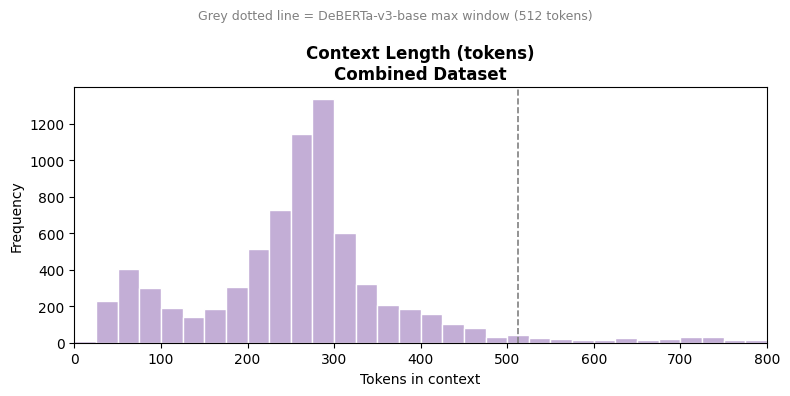

In [48]:
# Plot Context Length of Training Dataset
MAX_LEN = 512    # DeBERTa-v3-base window
XMAX    = 800    # x-axis cap
BIN_STEP = 25     # bin width

plt.figure(figsize=(8, 4))
plt.hist(
    combined_df['context_tok_len'],
    bins=np.arange(0, XMAX + BIN_STEP, BIN_STEP),
    color='#C3AED6',            # light purple
    edgecolor='white'
)
plt.axvline(MAX_LEN, linestyle='--', color='grey', linewidth=1.2)
plt.xlim(0, XMAX)
plt.title("Context Length (tokens)\nCombined Dataset", fontweight='bold'),
#plt.subtitle("Combined Dataset", fontweight='bold'),
plt.suptitle("Grey dotted line = DeBERTa-v3-base max window (512 tokens)",
             fontsize=9, color='grey')
plt.xlabel("Tokens in context")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

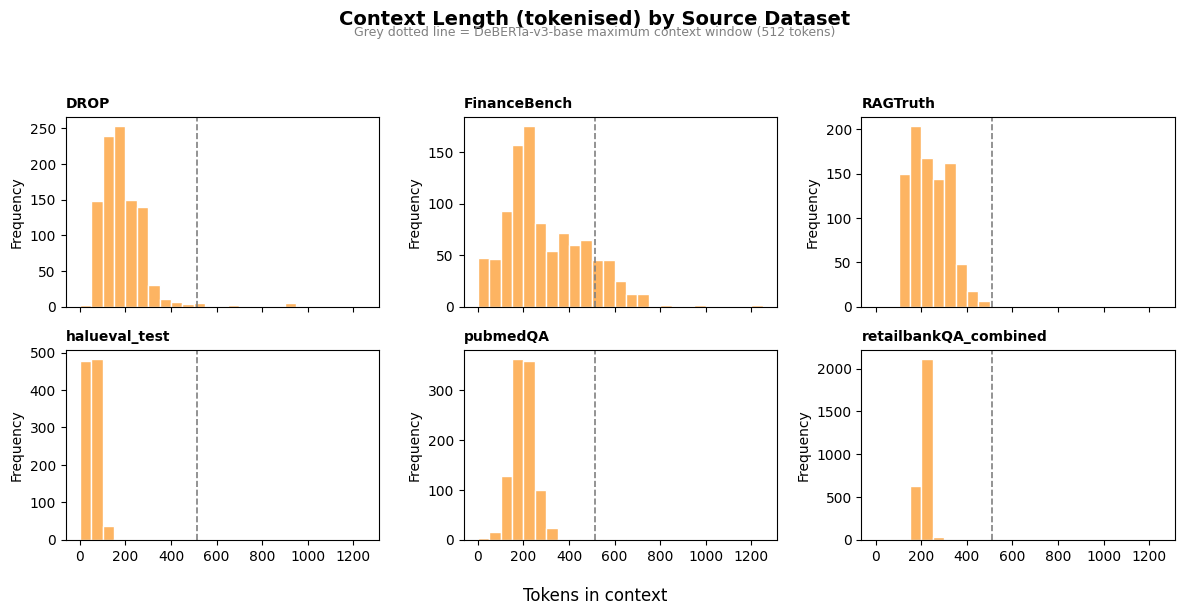

In [49]:
# Plot Context Length of Training Dataset by Data Source
combined_df['context_tok_len'] = combined_df['context'].str.split().str.len()
sources = sorted(combined_df['source_ds_temp'].unique())
n_src   = len(sources)
n_cols  = 3
n_rows  = math.ceil(n_src / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3.2), sharex=True, sharey=False)
axes = axes.flatten()

for ax, src in zip(axes, sources):
    subset = combined_df[combined_df['source_ds_temp'] == src]
    ax.hist(
        subset['context_tok_len'],
        bins=np.arange(0, subset['context_tok_len'].max() + 50, 50),
        color='#FDB462', edgecolor='white'
    )
    ax.axvline(MAX_LEN, linestyle='--', color='grey', linewidth=1.2)
    ax.set_title(src, loc='left', fontweight='bold', fontsize=10)
    ax.set_ylabel("Frequency")

for i in range(len(sources), len(axes)):
    axes[i].axis('off')

fig.suptitle("Context Length (tokenised) by Source Dataset",
             fontsize=14, fontweight='bold', y=0.94)
fig.text(0.5, 0.90,
         "Grey dotted line = DeBERTa-v3-base maximum context window (512 tokens)",
         ha='center', fontsize=9, color='grey')

fig.supxlabel("Tokens in context")
#fig.supylabel("Frequency")

plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.show()

In [50]:
# Check the number of examples created
print(f"Total training examples: {len(train_combined)}")
print(f"Total chunked training examples: {len(train_ds)}")
# View one example
print(train_ds [0])

#  Check length of input_ids (should be ≤ 512)
lengths = [len(x['input_ids']) for x in train_ds]
print(f"Min length: {min(lengths)}")
print(f"Max length: {max(lengths)}")

# Manually decode to verify the structure
decoded = tokenizer.decode(train_ds[0]['input_ids'], skip_special_tokens=False)
print(decoded)

#Check that labels are intact after chunking:
print(Counter(train_ds['labels']))

# Extract original index from chunk_id
df_chunks = pd.DataFrame(train_ds)
df_chunks['original_idx'] = df_chunks['chunk_id'].apply(lambda x: int(x.split('_')[0]))

# Count how many chunks per original row
chunk_counts = df_chunks['original_idx'].value_counts()
print(chunk_counts.describe())

Total training examples: 4430
Total chunked training examples: 7607
{'input_ids': [1, 44029, 272, 274, 281, 266, 613, 20135, 7343, 260, 10519, 262, 776, 900, 293, 3576, 478, 439, 272, 269, 1569, 267, 262, 916, 974, 1502, 1548, 294, 339, 269, 13325, 974, 1276, 280, 268, 475, 395, 1210, 265, 751, 265, 3244, 1758, 283, 266, 4639, 265, 2606, 292, 15189, 6661, 264, 15189, 66347, 302, 10519, 267, 2339, 265, 864, 268, 263, 1489, 264, 311, 26385, 470, 260, 2, 1259, 260, 765, 440, 2, 64275, 578, 260, 67886, 82520, 430, 2400, 38407, 16273, 63670, 23265, 30518, 13325, 974, 1276, 66944, 121932, 8988, 31011, 82520, 430, 2487, 112302, 287, 547, 3543, 261, 2488, 605, 752, 3909, 285, 2292, 2026, 1374, 1947, 261, 16789, 5070, 1112, 12437, 67868, 6615, 419, 706, 261, 23686, 419, 989, 261, 50174, 419, 621, 261, 38402, 4613, 1698, 456, 261, 50482, 453, 261, 55372, 453, 261, 38085, 6090, 2161, 7566, 602, 261, 44987, 940, 261, 45520, 1154, 261, 22029, 12437, 48790, 6938, 265, 4027, 404, 261, 21199, 404, 261

In [51]:
# Token count stats for response
train_combined["response_token_count"] = train_combined["response"].apply(lambda x: len(tokenizer.tokenize(str(x))))
token_count_stats = train_combined.groupby("label")["response_token_count"].describe()

print("\nToken Count Stats by Label (from training set):")
print(token_count_stats)


Token Count Stats by Label (from training set):
        count       mean        std  min  25%   50%    75%    max
label                                                            
0      2012.0  73.605865  72.061118  1.0  9.0  64.0  106.0  410.0
1      2418.0  85.442101  74.658412  1.0  8.0  73.0  140.0  340.0


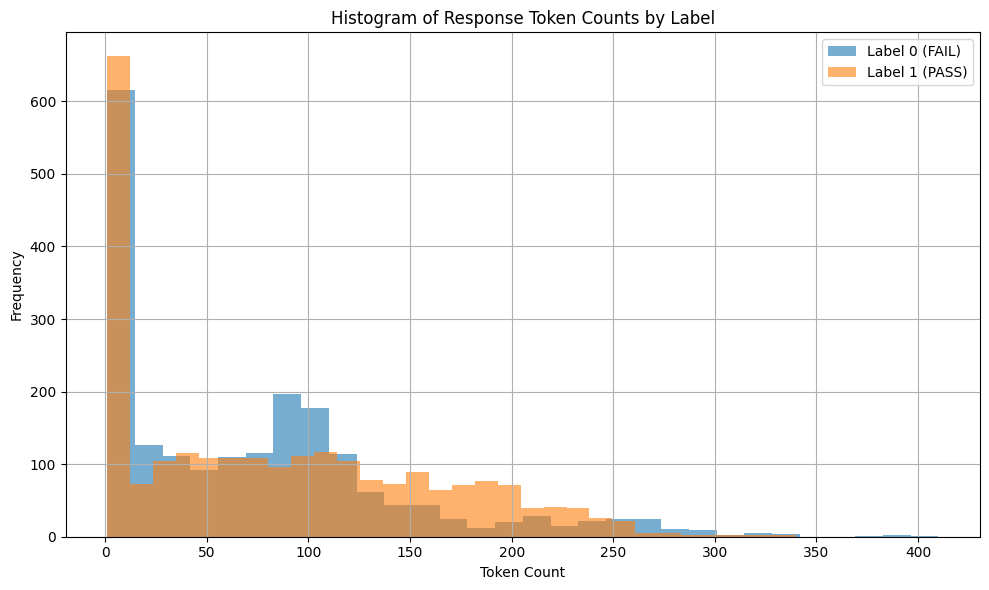

In [52]:
# Plot histogram of token counts by label
plt.figure(figsize=(10, 6))
for label in sorted(train_combined["label"].unique()):
    subset = train_combined[train_combined["label"] == label]
    plt.hist(
        subset["response_token_count"],
        bins=30,
        alpha=0.6,
        label=f"Label {label} ({'PASS' if label == 1 else 'FAIL'})"
    )

plt.title("Histogram of Response Token Counts by Label")
plt.xlabel("Token Count")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 3  Define evaluation metrics

In [53]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc, 'precision': precision, 'recall': recall, 'f1': f1}

## 6  Fine‑tune DeBERTa‑v3‑base with classification head

In [54]:
# Assess different hyperparameters and save per-run results
param_grid = {
    'learning_rate': [1e-5],
    'per_device_train_batch_size': [8],
    'num_train_epochs': [3],
}

results = []

for lr, bs, epochs in itertools.product(
    param_grid['learning_rate'],
    param_grid['per_device_train_batch_size'],
    param_grid['num_train_epochs']
):
    print(f"Running run: lr={lr}, batch_size={bs}, epochs={epochs}")

    run_name = f"lr{lr}_bs{bs}_ep{epochs}"

    training_args = TrainingArguments(
        output_dir =f"./results/{run_name}",
        eval_strategy='epoch',
        save_strategy='epoch',
        learning_rate=lr,
        per_device_train_batch_size=bs,
        per_device_eval_batch_size=bs,
        num_train_epochs=epochs,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model='f1',
        logging_steps=20,
        report_to='none'
    )

    model = AutoModelForSequenceClassification.from_pretrained(
        'microsoft/deberta-v3-base',
        num_labels=2
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        tokenizer=tokenizer,
        data_collator=DataCollatorWithPadding(tokenizer),
        compute_metrics=compute_metrics,
    )

    train_output = trainer.train()
    eval_metrics = trainer.evaluate()

    train_metrics = train_output.metrics

    run_record = {
        "run_name": run_name,
        "learning_rate": lr,
        "batch_size": bs,
        "epochs": epochs,
        **{f"train_{k}": v for k, v in train_metrics.items()},
        **{f"eval_{k}": v for k, v in eval_metrics.items()},
    }

    results.append(run_record)

df_results = pd.DataFrame(results)
print("\n=== Grid Search Results ===")
print(df_results)                          # Show table in-notebook
df_results.to_csv('grid_search_results.csv', index=False)

Running run: lr=1e-05, batch_size=8, epochs=3


pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-54-408288691.py:39: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.412700,0.534749,0.720656,0.755556,0.748552,0.752037
2,0.363900,0.556155,0.740328,0.743483,0.826188,0.782656
3,0.262300,0.656986,0.742295,0.751068,0.814600,0.781545



=== Grid Search Results ===
          run_name  learning_rate  batch_size  epochs  train_train_runtime  \
0  lr1e-05_bs8_ep3        0.00001           8       3            3106.6121   

   train_train_samples_per_second  train_train_steps_per_second  \
0                           7.346                         0.918   

   train_total_flos  train_train_loss  train_epoch  eval_eval_loss  \
0      5.822141e+15          0.390144          3.0        0.556155   

   eval_eval_accuracy  eval_eval_precision  eval_eval_recall  eval_eval_f1  \
0            0.740328             0.743483          0.826188      0.782656   

   eval_eval_runtime  eval_eval_samples_per_second  \
0             67.133                        22.716   

   eval_eval_steps_per_second  eval_epoch  
0                       2.845         3.0  


In [62]:
# Run inference on the three datasets but the chunked datasets.
def run_eval_on_chunked_set(dataset, original_df, dataset_name):
    print(f"Evaluating on: {dataset_name}")

    # 1. Run model inference
    raw_pred = trainer.predict(dataset)
    chunk_logits = raw_pred.predictions
    chunk_probs = torch.softmax(torch.tensor(chunk_logits), dim=1).numpy()
    chunk_labels = np.argmax(chunk_probs, axis=1)

    # 2. Construct DataFrame per chunk
    df_chunks = pd.DataFrame({
        "test_case_id": dataset['example_id'],
        "chunk_id": dataset["chunk_id"],
        "pred_prob": chunk_probs[:, 1],  # Probability of label 1 (PASS)
        "pred_label": chunk_labels
    })

    # 3. Aggregate: max probability per test_case_id
    df_chunks["max_pred_prob"] = df_chunks.groupby("test_case_id")["pred_prob"].transform("max")
    df_chunks["example_pred_label"] = (df_chunks["max_pred_prob"] >= 0.5).astype(int)

    # 4. Merge with ground truth labels (assumes 'label' column in original_df)
    original_df = original_df.rename(columns={"label": "true_label", "id": "test_case_id"})
    df_merged = df_chunks.drop_duplicates(subset=["test_case_id"]).merge(
        original_df[["test_case_id", "true_label", "source_ds"]], on="test_case_id", how="left"
    )
    df_merged["source"] = dataset_name

    # 5. Print classification report
    print("\n Example-level classification report:")
    print(classification_report(df_merged["true_label"], df_merged["example_pred_label"], target_names=["FAIL", "PASS"]))

    return df_chunks, df_merged

# Run on each test set
halubench_chunks_df, halubench_example_df = run_eval_on_chunked_set(halubench_test_ds, halubench_test, "halubench")
retailbank_chunks_df, retailbank_example_df = run_eval_on_chunked_set(retailbankQA_test_ds, retailbankQA_test, "retailbankQA_test")
#halueval_chunks_df, halueval_example_df = run_eval_on_chunked_set(halueval_test_ds, halueval_test, "halueval_test")

# Combine all and print global report
combined_eval_df = pd.concat([halubench_example_df, retailbank_example_df], ignore_index=True)
print("\n Combined classification report (all sources):")
print(classification_report(combined_eval_df["true_label"], combined_eval_df["example_pred_label"], target_names=["FAIL", "PASS"]))


Evaluating on: halubench



 Example-level classification report:
              precision    recall  f1-score   support

        FAIL       0.70      0.52      0.60       249
        PASS       0.70      0.83      0.76       335

    accuracy                           0.70       584
   macro avg       0.70      0.68      0.68       584
weighted avg       0.70      0.70      0.69       584

Evaluating on: retailbankQA_test



 Example-level classification report:
              precision    recall  f1-score   support

        FAIL       0.99      0.94      0.97       385
        PASS       0.95      0.99      0.97       385

    accuracy                           0.97       770
   macro avg       0.97      0.97      0.97       770
weighted avg       0.97      0.97      0.97       770


 Combined classification report (all sources):
              precision    recall  f1-score   support

        FAIL       0.89      0.78      0.83       634
        PASS       0.82      0.92      0.87       720

    accuracy                           0.85      1354
   macro avg       0.86      0.85      0.85      1354
weighted avg       0.85      0.85      0.85      1354



In [63]:
print("Classification report by source_ds in halubench:")

for source_name, group in halubench_example_df.groupby("source_ds"):
    print(f"Source DS: {source_name}")
    print(classification_report(group["true_label"], group["example_pred_label"], target_names=["FAIL", "PASS"]))


Classification report by source_ds in halubench:
Source DS: DROP
              precision    recall  f1-score   support

        FAIL       0.90      0.86      0.88        74
        PASS       0.86      0.90      0.88        68

    accuracy                           0.88       142
   macro avg       0.88      0.88      0.88       142
weighted avg       0.88      0.88      0.88       142

Source DS: FinanceBench
              precision    recall  f1-score   support

        FAIL       0.53      0.28      0.37        88
        PASS       0.52      0.76      0.62        90

    accuracy                           0.52       178
   macro avg       0.53      0.52      0.49       178
weighted avg       0.53      0.52      0.49       178

Source DS: RAGTruth
              precision    recall  f1-score   support

        FAIL       0.35      0.35      0.35        23
        PASS       0.85      0.85      0.85       101

    accuracy                           0.76       124
   macro avg       

In [64]:
# Save down the results
halubench_chunks_df.to_csv("halubench_chunks_df.csv", index=False)
halubench_example_df.to_csv("halubench_example_df.csv", index=False)
retailbank_chunks_df.to_csv("retailbank_chunks_df.csv", index=False)
retailbank_example_df.to_csv("retailbank_example_df.csv", index=False)

In [65]:
import csv
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

summary = []

for source, group in halubench_example_df.groupby("source_ds"):
    y_true = group["true_label"]
    y_pred = group["example_pred_label"]
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", pos_label=1)
    acc = accuracy_score(y_true, y_pred)
    summary.append({
        "source_ds": source,
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "n_samples": len(group)
    })

with open("classification_report_by_source.csv", "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=summary[0].keys())
    writer.writeheader()
    writer.writerows(summary)


In [59]:
trainer.save_model('deberta_crossencoder_halueval')
tokenizer.save_pretrained('deberta_crossencoder_halueval')

('deberta_crossencoder_halueval/tokenizer_config.json',
 'deberta_crossencoder_halueval/special_tokens_map.json',
 'deberta_crossencoder_halueval/spm.model',
 'deberta_crossencoder_halueval/added_tokens.json',
 'deberta_crossencoder_halueval/tokenizer.json')

In [1]:
#from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Load the tokenizer
#tokenizer = AutoTokenizer.from_pretrained("deberta_crossencoder_halueval")

# Load the model (assumes it's a sequence classification model)
#model = AutoModelForSequenceClassification.from_pretrained("deberta_crossencoder_halueval")

#from transformers import Trainer
#trainer = Trainer(model=model)
